In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import cvxpy as cvx
import riskfolio as rf

import statsmodels.api as sm

import scipy.stats as st
from scipy.linalg import expm, logm, sqrtm

import datetime as dt
from arch import arch_model

from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

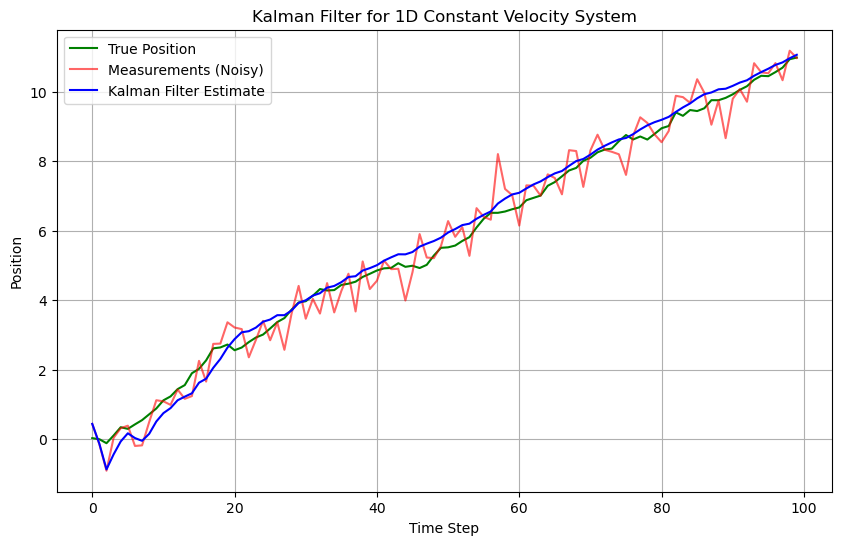

In [2]:
import numpy as np
from filterpy.kalman import KalmanFilter
import matplotlib.pyplot as plt

# 1. Define the system parameters
dt = 0.1  # Time step
initial_position = 0.0
initial_velocity = 1.0
process_noise_std = 0.1  # Standard deviation of process noise
measurement_noise_std = 0.5  # Standard deviation of measurement noise

# 2. Initialize the Kalman Filter
kf = KalmanFilter(dim_x=2, dim_z=1) # dim_x: state vector size (position, velocity), dim_z: measurement vector size (position)

# Initial state estimate (x, velocity)
kf.x = np.array([[initial_position], [initial_velocity]])

# Initial state covariance matrix (P) - high uncertainty initially
kf.P = np.array([[1000., 0.],
                 [0., 1000.]])

# State transition matrix (F) - constant velocity model
# x_k = x_{k-1} + v_{k-1}*dt
# v_k = v_{k-1}
kf.F = np.array([[1., dt],
                 [0., 1.]])

# Measurement function matrix (H) - we only measure position
kf.H = np.array([[1., 0.]])

# Process noise covariance matrix (Q)
# Represents uncertainty in the system's dynamics
kf.Q = np.array([[0.25 * dt**4, 0.5 * dt**3],
                 [0.5 * dt**3, dt**2]]) * process_noise_std**2

# Measurement noise covariance matrix (R)
# Represents uncertainty in the measurements
kf.R = np.array([[measurement_noise_std**2]])

# 3. Simulate the system and apply the Kalman Filter
num_steps = 100
true_states = []
measurements = []
filtered_states = []

true_position = initial_position
true_velocity = initial_velocity

for _ in range(num_steps):
    # Simulate true state
    true_position += true_velocity * dt + np.random.randn() * process_noise_std
    # true_velocity is assumed constant for simplicity in this example
    true_states.append(true_position)

    # Simulate noisy measurement
    measurement = true_position + np.random.randn() * measurement_noise_std
    measurements.append(measurement)

    # Kalman Filter predict step
    kf.predict()

    # Kalman Filter update step
    kf.update(np.array([[measurement]]))

    filtered_states.append(kf.x[0, 0]) # Store estimated position

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(true_states, label='True Position', color='green')
plt.plot(measurements, label='Measurements (Noisy)', color='red', alpha=0.6)
plt.plot(filtered_states, label='Kalman Filter Estimate', color='blue')
plt.title('Kalman Filter for 1D Constant Velocity System')
plt.xlabel('Time Step')
plt.ylabel('Position')
plt.legend()
plt.grid(True)
plt.show()